In [20]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

In [115]:
data_path = 'data/TOY2/train/img'
imgs = [cv.imread(f"{data_path}/{img}") for img in os.listdir(data_path)]
sample_imgs = imgs[:8]

## Inspect images

In [116]:
def plot_samples(imgs):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111,  # similar to subplot(111)
                    nrows_ncols=(2, 4),  # creates 2x2 grid of Axes
                    axes_pad=0.1,  # pad between Axes in inch.
                    )

    for ax, im in zip(grid, imgs):
        # Iterating over the grid returns the Axes.
        ax.imshow(im)

    plt.show()

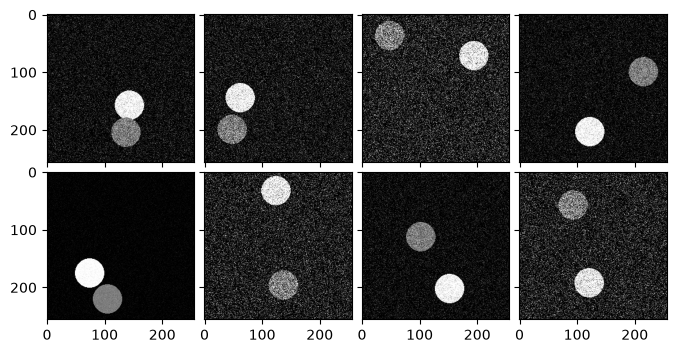

In [117]:
plot_samples(sample_imgs)

## Preprocessing 1: noise reduction

In [118]:
from scipy.ndimage import gaussian_filter
import scipy.ndimage

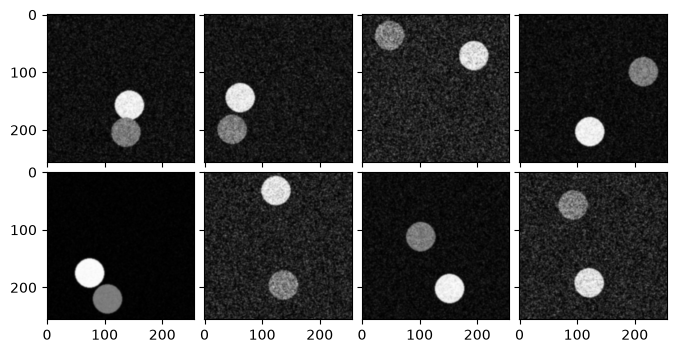

In [ ]:
filtered_imgs = [gaussian_filter(img, sigma=1) for img in sample_imgs]
plot_samples(filtered_imgs)

In [120]:
import cv2 as cv

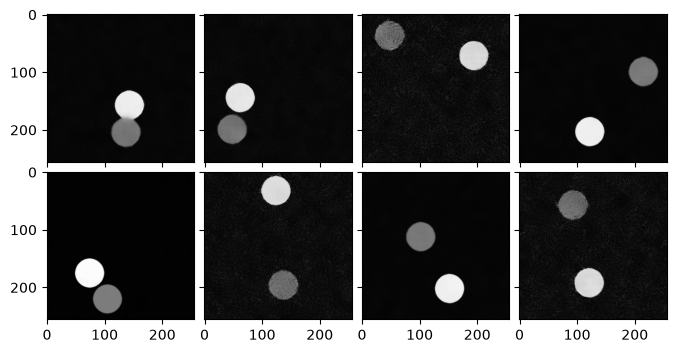

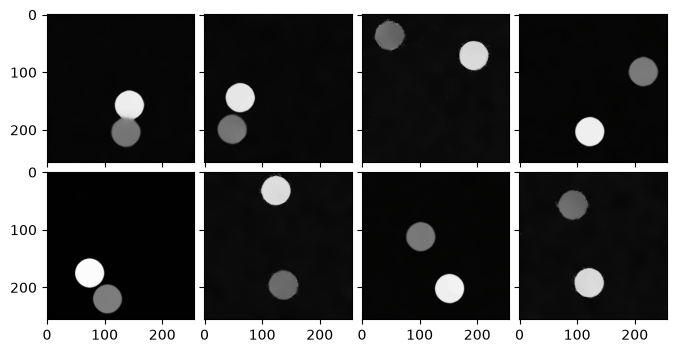

In [121]:
filtered_imgs = [cv.fastNlMeansDenoisingColored(img,None,50,50,7,21) for img in sample_imgs]
plot_samples(filtered_imgs)
filtered_imgs = [cv.fastNlMeansDenoisingColored(img,None,20,20,7,21) for img in filtered_imgs]

plot_samples(filtered_imgs)

## Preprocessing 2: sharpen edges

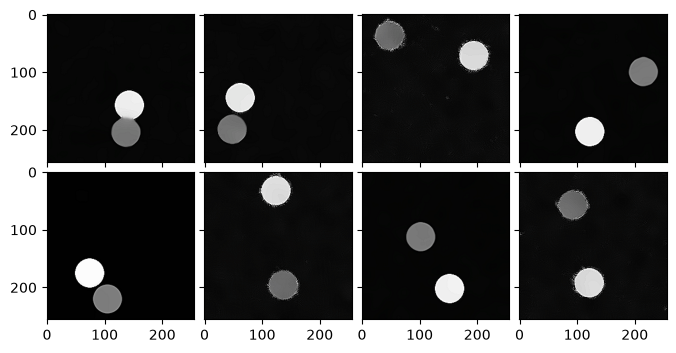

In [122]:
# Create sharpening kernel
kernel = np.array([[0, -1, 0], 
                   [-1, 5, -1],
                   [0, -1, 0]])

# Apply sharpening
sharpened_imgs = [cv.filter2D(img, -1, kernel) for img in filtered_imgs]
plot_samples(sharpened_imgs)

## Preprocessing 3: erosion

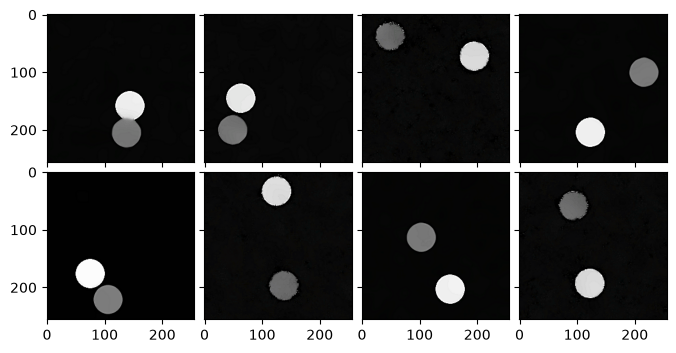

In [ ]:
kernel = np.ones((2,2),np.uint8)
opened_imgs = [cv.morphologyEx(img, cv.MORPH_OPEN, kernel) for img in sharpened_imgs]
closed_imgs = [cv.morphologyEx(img, cv.MORPH_CLOSE, kernel) for img in opened_imgs]

plot_samples(closed_imgs)

In [134]:
shaped_imgs = []
for img in closed_imgs:
    img = np.dot(img[..., :3], [0.299, 0.587, 0.114])
    img = img[None, ...]
    shaped_imgs.append(img)